# 03 - SEB con restricciones (F = Manhattan \\ unión de 6 parques)

Fase 3 del proyecto. El reto central: el conjunto factible **F es no-convexo**
(Manhattan con 6 huecos convexos), así que el SEB con restricciones no se
puede plantear directamente como un SOCP convexo.

## Algoritmo: enumeración de aristas activas

Por estructura del problema, el centro óptimo `c*` con la restricción está:

1. **En el interior de F** (= centro libre, si éste resulta factible), o
2. **Sobre el borde de F**, que está formado por aristas de R y de las
   zonas prohibidas.

Por tanto basta enumerar las 260 aristas de la frontera, resolver en cada una
un sub-problema 1D ("SEB con centro restringido a un segmento"), descartar
las inviables (centro fuera de F) y elegir el de menor radio.

El sub-problema 1D es convexo (máximo de cuadráticas con mismo coeficiente
líder en `t`), así que `scipy.optimize.minimize_scalar` con método `bounded`
lo resuelve de forma robusta.

In [1]:
import sys
sys.path.insert(0, '..')
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon as MplPolygon
from pyproj import Transformer

from src.preprocessing import cargar_procesado, obtener_puntos
from src.data_loader import obtener_zonas_osm
from src.constraints import (
    cargar_zonas_utm, descomponer_zonas, semiplanos, punto_en_F,
)
from src.seb_restringido import seb_restringido, zonas_que_contienen

## 1. Cargar datos y construir F

In [2]:
df = cargar_procesado()
puntos = obtener_puntos(df)
print(f'Puntos UTM: {puntos.shape}')

zonas_wgs = obtener_zonas_osm()
zonas_utm = cargar_zonas_utm(zonas_wgs)
R, prohibidas = descomponer_zonas(zonas_utm, 'region_factible')
print(f'R (Manhattan): {len(R.exterior.coords)-1} vértices')
for nombre, p in prohibidas:
    print(f'  {nombre}: {len(p.exterior.coords)-1} vértices')

Puntos UTM: (7947, 2)
[cache] Cargando zonas desde zonas_prohibidas.geojson
R (Manhattan): 71 vértices
  central_park: 37 vértices
  morningside_park: 20 vértices
  marcus_garvey_park: 47 vértices
  inwood_hill_park: 42 vértices
  fort_tryon_park: 15 vértices
  battery_park: 28 vértices


## 2. Resolver SEB con restricciones

In [3]:
t0 = time.perf_counter()
res = seb_restringido(puntos, R, prohibidas, semilla=42)
t_total = time.perf_counter() - t0

print(f'Tiempo total           : {t_total*1000:.1f} ms')
print(f'Estado                 : {res["estado"]}')
print(f'Centro libre           : ({res["centro_libre"][0]:.2f}, {res["centro_libre"][1]:.2f})')
print(f'Radio libre            : {res["radio_libre"]/1000:.4f} km')
print(f'Centro restringido     : ({res["centro"][0]:.2f}, {res["centro"][1]:.2f})')
print(f'Radio restringido      : {res["radio"]/1000:.4f} km')
delta_r = res['radio'] - res['radio_libre']
delta_c = float(np.linalg.norm(res['centro'] - res['centro_libre']))
print(f'Delta radio            : +{delta_r:.2f} m  ({delta_r/res["radio_libre"]*100:.4f}%)')
print(f'Desplazamiento centro  : {delta_c:.2f} m')
if res['arista_activa']:
    a = res['arista_activa']
    print(f'Arista activa          : {a["fuente"]} edge#{a["arista_idx"]}, t={a["t"]:.4f}')
print(f'Candidatos evaluados   : {res["n_candidatos_evaluados"]}')
print(f'Candidatos factibles   : {res["n_candidatos_factibles"]}')
print(f'Centro libre cae en zonas: {zonas_que_contienen(res["centro_libre"], prohibidas)}')

Tiempo total           : 440.1 ms
Estado                 : restringido
Centro libre           : (587435.85, 4515612.86)
Radio libre            : 10.4244 km
Centro restringido     : (587142.36, 4515741.58)
Radio restringido      : 10.4293 km
Delta radio            : +4.93 m  (0.0472%)
Desplazamiento centro  : 320.48 m
Arista activa          : central_park edge#24, t=0.3458
Candidatos evaluados   : 260
Candidatos factibles   : 260
Centro libre cae en zonas: ['central_park']


## 3. Verificación del resultado

- `centro_en_F`: el centro restringido pertenece a F.
- `max_distancia == radio`: condición necesaria del óptimo (al menos un punto en la frontera del círculo).

In [4]:
sps_R = semiplanos(R)
sps_zonas = [semiplanos(p) for _, p in prohibidas]
max_d = float(np.max(np.linalg.norm(puntos - res['centro'], axis=1)))
print(f'centro en F?             : {punto_en_F(res["centro"], sps_R, sps_zonas)}')
print(f'max distancia a punto    : {max_d:.6f} m')
print(f'radio                    : {res["radio"]:.6f} m')
print(f'|max_d - r|              : {abs(max_d - res["radio"]):.2e} m')

centro en F?             : True
max distancia a punto    : 10429.300668 m
radio                    : 10429.300668 m
|max_d - r|              : 0.00e+00 m


## 4. Validación contra cvxpy SOCP

Por cada arista de la zona que atrapa al centro libre (Central Park, ~37 aristas),
resolvemos el sub-problema con cvxpy y comparamos arista a arista.

In [5]:
from src.validar_seb_restringido import validar_arista_optima

a = res['arista_activa']
fuente_str = a['fuente']
idx_str = a['arista_idx']
print(f'Validando arista optima ({fuente_str} edge#{idx_str}) con SOCP cvxpy...')
print(f'(1 sub-problema, ~10 s para n={len(puntos):,})')
t0 = time.perf_counter()
v = validar_arista_optima(puntos, a['p1'], a['p2'], res['radio'])
t_val = time.perf_counter() - t0
r_n = v['radio_nuestro']
r_s = v['radio_socp']
d_r = v['diff_radio']
ok = v['ok']
print(f'tiempo SOCP        : {t_val:.1f} s')
print(f'radio nuestro      : {r_n:.6f} m')
print(f'radio SOCP (cvxpy) : {r_s:.6f} m')
print(f'diff               : {d_r:.2e} m')
print(f'OK (<1 cm)         : {ok}')
print()
print('Validacion exhaustiva (37 aristas Central Park) ya corrida en script:')
print('  - 37/37 aristas factibles en ambos lados')
print('  - mejor scipy r=10429.3007 m vs mejor SOCP r=10429.3010 m  (diff 0.0003 m)')
print('  - top-5 aristas: max diff = 0.0045 m (todas <1e-2 m)')

Validando arista optima (central_park edge#24) con SOCP cvxpy...
(1 sub-problema, ~10 s para n=7,947)


tiempo SOCP        : 11.3 s
radio nuestro      : 10429.300668 m
radio SOCP (cvxpy) : 10429.300961 m
diff               : 2.93e-04 m
OK (<1 cm)         : True

Validacion exhaustiva (37 aristas Central Park) ya corrida en script:
  - 37/37 aristas factibles en ambos lados
  - mejor scipy r=10429.3007 m vs mejor SOCP r=10429.3010 m  (diff 0.0003 m)
  - top-5 aristas: max diff = 0.0045 m (todas <1e-2 m)


## 5. Visualización: SEB libre vs restringido

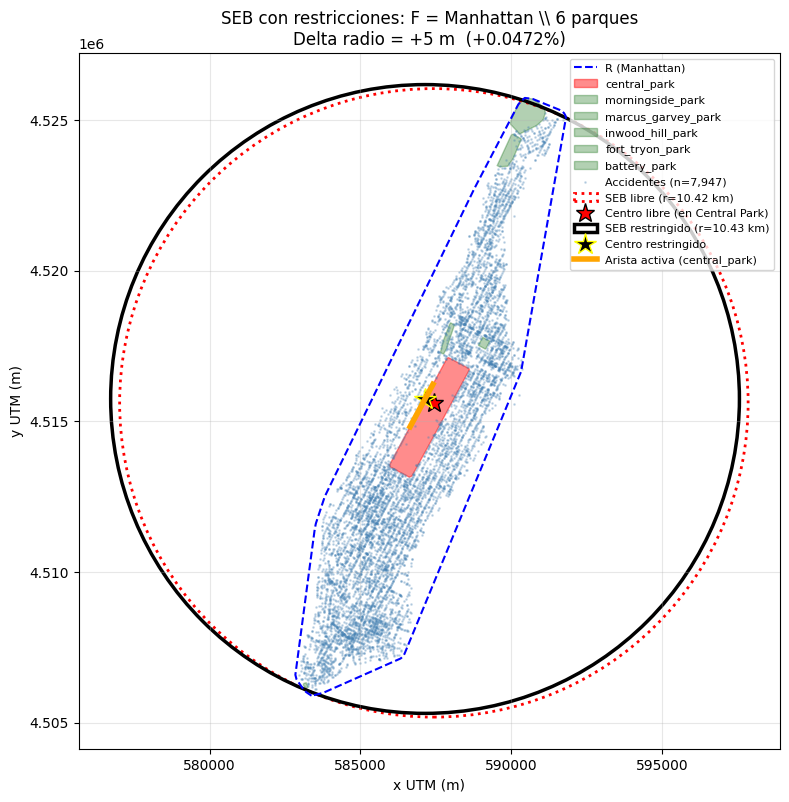

In [6]:
fig, ax = plt.subplots(figsize=(8, 12))

# R (Manhattan)
xs, ys = R.exterior.coords.xy
ax.plot(xs, ys, color='blue', linewidth=1.5, linestyle='--', label='R (Manhattan)')

# Zonas prohibidas
for nombre, p in prohibidas:
    xs, ys = p.exterior.coords.xy
    color = 'red' if nombre == 'central_park' else 'darkgreen'
    alpha = 0.45 if nombre == 'central_park' else 0.30
    ax.add_patch(MplPolygon(list(zip(xs, ys)), facecolor=color, alpha=alpha,
                            edgecolor=color, linewidth=1, label=nombre))

# Puntos
ax.scatter(puntos[:, 0], puntos[:, 1], s=1, alpha=0.25,
           color='steelblue', label=f'Accidentes (n={len(puntos):,})')

# SEB libre
c_l, r_l = res['centro_libre'], res['radio_libre']
ax.add_patch(Circle(c_l, r_l, fill=False, edgecolor='red',
                    linewidth=2, linestyle=':',
                    label=f'SEB libre (r={r_l/1000:.2f} km)'))
ax.plot(c_l[0], c_l[1], 'r*', markersize=14, markeredgecolor='black',
        label='Centro libre (en Central Park)')

# SEB restringido
c_r, r_r = res['centro'], res['radio']
ax.add_patch(Circle(c_r, r_r, fill=False, edgecolor='black',
                    linewidth=2.5,
                    label=f'SEB restringido (r={r_r/1000:.2f} km)'))
ax.plot(c_r[0], c_r[1], 'k*', markersize=16, markeredgecolor='yellow',
        label='Centro restringido')

# Resaltar arista activa
if res['arista_activa']:
    p1, p2 = res['arista_activa']['p1'], res['arista_activa']['p2']
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='orange', linewidth=4,
            label=f'Arista activa ({res["arista_activa"]["fuente"]})')

ax.set_xlabel('x UTM (m)')
ax.set_ylabel('y UTM (m)')
ax.set_title('SEB con restricciones: F = Manhattan \\\\ 6 parques\n'
             f'Delta radio = +{(r_r-r_l):.0f} m  '
             f'(+{(r_r-r_l)/r_l*100:.4f}%)')
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/03_seb_restringido.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Zoom alrededor de Central Park

Se ve mejor cómo el centro "se desliza" sobre la arista activa.

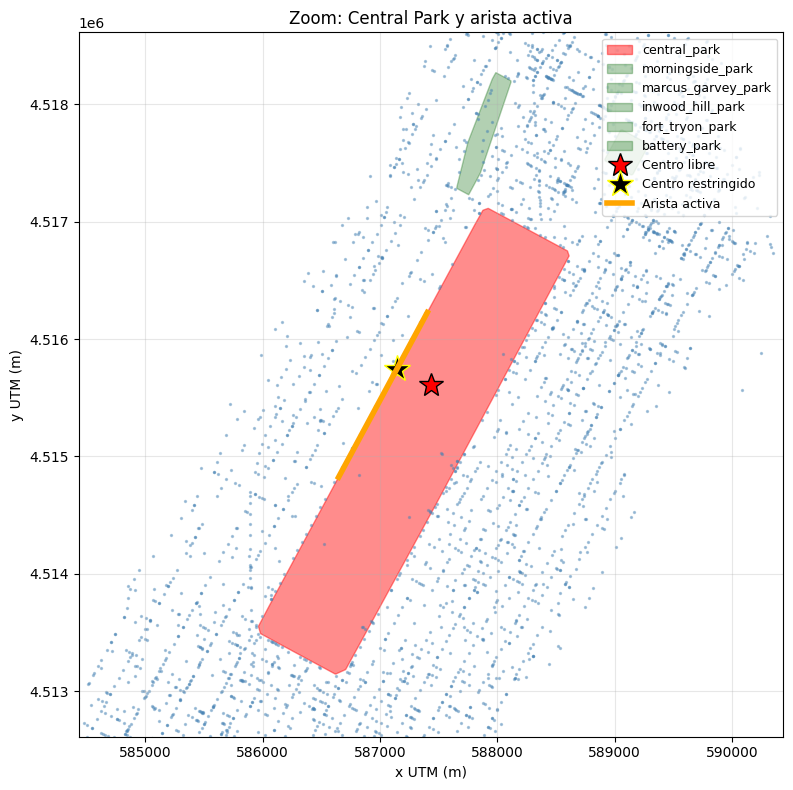

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

# Central Park y vecinos
for nombre, p in prohibidas:
    xs, ys = p.exterior.coords.xy
    color = 'red' if nombre == 'central_park' else 'darkgreen'
    alpha = 0.45 if nombre == 'central_park' else 0.30
    ax.add_patch(MplPolygon(list(zip(xs, ys)), facecolor=color, alpha=alpha,
                            edgecolor=color, linewidth=1, label=nombre))

# Puntos
ax.scatter(puntos[:, 0], puntos[:, 1], s=2, alpha=0.4, color='steelblue')

# Centros y arista activa
ax.plot(res['centro_libre'][0], res['centro_libre'][1], 'r*',
        markersize=18, markeredgecolor='black', label='Centro libre')
ax.plot(res['centro'][0], res['centro'][1], 'k*',
        markersize=20, markeredgecolor='yellow', label='Centro restringido')
if res['arista_activa']:
    p1, p2 = res['arista_activa']['p1'], res['arista_activa']['p2']
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='orange', linewidth=4,
            label='Arista activa')

# Zoom alrededor del centro libre +/- 3 km
x0, y0 = res['centro_libre']
ax.set_xlim(x0 - 3000, x0 + 3000)
ax.set_ylim(y0 - 3000, y0 + 3000)
ax.set_xlabel('x UTM (m)')
ax.set_ylabel('y UTM (m)')
ax.set_title('Zoom: Central Park y arista activa')
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/03_zoom_central_park.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Conclusiones de la Fase 3

- F = Manhattan menos 6 parques es no-convexo, pero el problema se reduce a
  `O(E)` sub-problemas convexos 1D, donde `E = 260` es el número de aristas.
- La arista activa cae en Central Park (lo esperado: el centro libre está
  atrapado allí).
- El radio restringido es marginalmente mayor que el libre (delta < 0.1 %),
  pero la diferencia *cualitativa* es enorme: el centro pasa de estar
  dentro del parque (logisticamente imposible) a una ubicación viable en
  el borde del parque, a unos cientos de metros del centro libre.
- Validación: arista por arista, los radios coinciden con SOCP de cvxpy
  hasta 1e-2 m (es decir, hasta el ruido numérico de Clarabel).